# DeepLense Test 1 - Multi-Class Lens Classification

This notebook presents a hybrid PyTorch pipeline for classifying single-channel galaxy images into the three DeepLense Test 1 categories: `no`, `sphere`, and `vort`. The training backbone, augmentation policy, and optimization setup are anchored to the original notebook because that version produced the stronger standard validation metrics, while a corrected Test-Time Augmentation (TTA) path is added as a supplemental inference-only enhancement.

## Notebook Goal
- Train a three-class classifier on `dataset/train`
- Reserve a stratified internal validation split for model selection
- Report standard validation metrics first, then TTA metrics as a supplemental comparison
- Use `dataset/val` only once at the end as a supplemental holdout check

## Hybrid Configuration
- Custom residual CNN trained from scratch on single-channel inputs
- Full training-split normalization statistics for reproducible standard metrics
- Original training augmentation policy: random flips plus small-angle rotations
- `CrossEntropyLoss` with label smoothing
- `AdamW`, `ReduceLROnPlateau`, and early stopping
- Best checkpoint selected only by standard internal validation macro AUC
- Symmetry-based raw-space TTA applied only during evaluation

The code below keeps the original notebook structure and reporting style, while merging in a safer inference-time TTA implementation that does not interfere with the stronger standard training setup.


In [1]:
import copy
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode

plt.style.use("seaborn-v0_8-whitegrid")

## Configuration And Runtime Setup

Set the reproducibility seed, training hyperparameters, runtime device, and dataset/artifact paths. Keeping these global settings together makes later reruns easier and establishes the notebook structure before any data is loaded.


In [2]:
# -- Config -------------------------------------------------------------------
SEED = 42
VAL_SIZE = 0.10
BATCH_SIZE = 256
EPOCHS = 50
LR = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
EARLY_STOP_PATIENCE = 5
NUM_WORKERS = 4
TTA_N = 8

# -- Paths --------------------------------------------------------------------
cwd = Path.cwd()
ROOT = cwd if (cwd / "dataset").exists() else cwd / "test1"
DATA_ROOT = ROOT / "dataset"
ARTIFACTS = ROOT / "artifacts_v2"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

# -- Labels -------------------------------------------------------------------
CLASS_NAMES = ["no", "sphere", "vort"]
CLASS_LABELS = ["No substructure", "Subhalo substructure", "Vortex substructure"]
NUM_CLASSES = len(CLASS_NAMES)

# -- Reproducibility -----------------------------------------------------------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin_memory = device.type == "cuda"

print(f"Device: {device}")
print(f"Data root: {DATA_ROOT}")


Device: cuda
Data root: /home/colin/gsoc26-deeplense/test1/dataset


## Data Loading And Split

Load the three class folders from `dataset/train` and `dataset/val`, then create a stratified internal validation split from the training portion. The displayed summary shows how samples are distributed across the train, internal validation, and holdout splits.


In [3]:
def load_split(split_name):
    paths, labels = [], []
    for label, class_name in enumerate(CLASS_NAMES):
        class_dir = DATA_ROOT / split_name / class_name
        class_paths = sorted(class_dir.glob("*.npy"))
        if not class_paths:
            raise FileNotFoundError(f"No .npy files found in {class_dir}")
        paths.extend(class_paths)
        labels.extend([label] * len(class_paths))
    return paths, labels


full_train_paths, full_train_labels = load_split("train")
holdout_paths, holdout_labels = load_split("val")

train_paths, val_paths, train_labels, val_labels = train_test_split(
    full_train_paths,
    full_train_labels,
    test_size=VAL_SIZE,
    stratify=full_train_labels,
    random_state=SEED,
)

split_counts = pd.DataFrame(
    {
        "split": ["train"] * len(train_labels)
        + ["internal_val"] * len(val_labels)
        + ["holdout"] * len(holdout_labels),
        "label": train_labels + val_labels + holdout_labels,
    }
)
split_counts["class_name"] = split_counts["label"].map(lambda i: CLASS_NAMES[i])
display(split_counts.groupby(["split", "class_name"]).size().unstack(fill_value=0))

print(f"Train samples: {len(train_paths):,}")
print(f"Internal val samples: {len(val_paths):,}")
print(f"Holdout samples: {len(holdout_paths):,}")


class_name,no,sphere,vort
split,,,
holdout,2500,2500,2500
internal_val,1000,1000,1000
train,9000,9000,9000


Train samples: 27,000
Internal val samples: 3,000
Holdout samples: 7,500


## Normalization Statistics

Compute scalar normalization statistics from the current training split only. The same mean and standard deviation are then reused by both the training and evaluation transforms so every split is normalized consistently.


In [4]:
total_sum = 0.0
total_sq = 0.0
total_pixels = 0

for path in train_paths:
    array = np.load(path).astype(np.float32)
    total_sum += float(array.sum())
    total_sq += float((array**2).sum())
    total_pixels += array.size

mean = total_sum / total_pixels
std = np.sqrt(max(total_sq / total_pixels - mean**2, 1e-12))

print(f"Mean: {mean:.6f}")
print(f"Std: {std:.6f}")


Mean: 0.061705
Std: 0.117299


## Dataset And DataLoaders

Define the dataset wrapper, the original training augmentation policy, and the standard evaluation data loaders. Training stays close to the stronger notebook baseline, while TTA is introduced later as a separate evaluation-only path so the standard model quality remains the primary objective.


In [5]:
class LensDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        image = torch.from_numpy(np.load(self.paths[index]).astype(np.float32))
        if self.transform is not None:
            image = self.transform(image)
        return image, self.labels[index]


train_transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20, interpolation=InterpolationMode.BILINEAR),
        transforms.Normalize([mean], [std]),
    ]
)

eval_transform = transforms.Normalize([mean], [std])

train_loader = DataLoader(
    LensDataset(train_paths, train_labels, train_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    LensDataset(val_paths, val_labels, eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)
holdout_loader = DataLoader(
    LensDataset(holdout_paths, holdout_labels, eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

sample_images, sample_labels = next(iter(train_loader))
print(f"Batch image shape: {tuple(sample_images.shape)}")
print(f"Batch labels shape: {tuple(sample_labels.shape)}")


Batch image shape: (256, 1, 150, 150)
Batch labels shape: (256,)


## Model Definition

Use the same custom residual CNN backbone as the original notebook. The network consumes single-channel inputs and produces logits for the three target classes `no`, `sphere`, and `vort`.


In [6]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = (
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
            if stride != 1 or in_channels != out_channels
            else nn.Identity()
        )

    def forward(self, x):
        out = torch.nn.functional.silu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return torch.nn.functional.silu(out + self.shortcut(x))


class LensResNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 5, 2, 2, bias=False),
            nn.BatchNorm2d(32),
            nn.SiLU(),
        )
        self.layer1 = nn.Sequential(ResidualBlock(32, 32), ResidualBlock(32, 32))
        self.layer2 = nn.Sequential(ResidualBlock(32, 64, 2), ResidualBlock(64, 64))
        self.layer3 = nn.Sequential(ResidualBlock(64, 128, 2), ResidualBlock(128, 128))
        self.layer4 = nn.Sequential(ResidualBlock(128, 256, 2), ResidualBlock(256, 256))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        return self.head(x)


model = LensResNet(num_classes=len(CLASS_NAMES)).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


Parameters: 2,795,747


## Training Helpers And Optimization Setup

Collect the evaluation helpers, reporting utilities, loss definition, optimizer, scheduler, checkpointing logic, and epoch loop in one place. Model selection still depends only on the best standard internal validation macro AUC, while TTA is treated as a supplemental inference-time analysis after training is complete.


In [7]:
# -- Evaluation Helpers --------------------------------------------------------
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_labels, all_probs = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=pin_memory)
            labels = labels.to(device, non_blocking=pin_memory)
            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)

            total_loss += loss.item() * len(images)
            all_labels.append(labels.cpu())
            all_probs.append(probs.cpu())

    labels_np = torch.cat(all_labels).numpy()
    probs_np = torch.cat(all_probs).numpy()
    preds_np = probs_np.argmax(axis=1)

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": float((preds_np == labels_np).mean()),
        "auc_macro": float(
            roc_auc_score(labels_np, probs_np, multi_class="ovr", average="macro")
        ),
        "labels": labels_np,
        "predictions": preds_np,
        "probabilities": probs_np,
    }


TTA_VIEWS = [
    (0, False),
    (1, False),
    (2, False),
    (3, False),
    (0, True),
    (1, True),
    (2, True),
    (3, True),
]


def apply_tta_view(images, rotation_k, flip_horizontal):
    augmented = torch.rot90(images, k=rotation_k, dims=(-2, -1))
    if flip_horizontal:
        augmented = torch.flip(augmented, dims=(-1,))
    return augmented


# The TTA path operates on raw images first and normalizes only after the
# spatial symmetry has been applied. This avoids the corner-fill artefacts that
# appear when rotations are performed on already-normalized tensors.
def evaluate_tta(model, paths, labels_list, criterion, n_aug=TTA_N):
    if not 1 <= n_aug <= len(TTA_VIEWS):
        raise ValueError(f"n_aug must be between 1 and {len(TTA_VIEWS)}")

    loader = DataLoader(
        LensDataset(paths, labels_list, transform=None),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model.eval()
    total_loss = 0.0
    all_labels, all_probs = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=pin_memory)
            labels = labels.to(device, non_blocking=pin_memory)
            probs_sum = None

            for view_idx, (rotation_k, flip_horizontal) in enumerate(TTA_VIEWS[:n_aug]):
                augmented = apply_tta_view(images, rotation_k, flip_horizontal)
                augmented = (augmented - mean) / std
                logits = model(augmented)
                probs = torch.softmax(logits, dim=1)

                if probs_sum is None:
                    probs_sum = probs
                    total_loss += criterion(logits, labels).item() * len(images)
                else:
                    probs_sum += probs

            all_labels.append(labels.cpu())
            all_probs.append((probs_sum / n_aug).cpu())

    labels_np = torch.cat(all_labels).numpy()
    probs_np = torch.cat(all_probs).numpy()
    preds_np = probs_np.argmax(axis=1)

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": float((preds_np == labels_np).mean()),
        "auc_macro": float(
            roc_auc_score(labels_np, probs_np, multi_class="ovr", average="macro")
        ),
        "labels": labels_np,
        "predictions": preds_np,
        "probabilities": probs_np,
    }


def summarize_split(title, results):
    labels = results["labels"]
    predictions = results["predictions"]
    probabilities = results["probabilities"]
    labels_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))

    print("=" * 60)
    print(title)
    print("=" * 60)
    print(f"Loss: {results['loss']:.4f}")
    print(f"Accuracy: {results['accuracy']:.4f}")
    print(f"Macro AUC: {results['auc_macro']:.4f}")

    print("Per-class AUC:")
    for i, class_name in enumerate(CLASS_NAMES):
        class_auc = roc_auc_score(labels_bin[:, i], probabilities[:, i])
        print(f"  {class_name}: {class_auc:.4f}")

    print("Classification Report:")
    print(
        classification_report(
            labels,
            predictions,
            target_names=CLASS_NAMES,
            zero_division=0,
        )
    )

    return labels, predictions, probabilities


# -- Optimization And Training Loop --------------------------------------------
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

best_auc = -float("inf")
best_state = copy.deepcopy(model.state_dict())
patience_counter = 0
history = []

# -- Training Loop -------------------------------------------------------------
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=pin_memory)
        labels = labels.to(device, non_blocking=pin_memory)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(images)
        train_correct += (logits.argmax(dim=1) == labels).sum().item()
        train_total += len(images)

    val_metrics = evaluate(model, val_loader, criterion)
    scheduler.step(val_metrics["auc_macro"])
    current_lr = optimizer.param_groups[0]["lr"]

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss / train_total,
            "train_acc": train_correct / train_total,
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["accuracy"],
            "val_auc": val_metrics["auc_macro"],
            "lr": current_lr,
        }
    )

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss/train_total:.4f} train_acc={train_correct/train_total:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['accuracy']:.4f} val_auc={val_metrics['auc_macro']:.4f} | "
        f"lr={current_lr:.2e}"
    )

    if val_metrics["auc_macro"] > best_auc:
        best_auc = val_metrics["auc_macro"]
        best_state = copy.deepcopy(model.state_dict())
        torch.save(
            {
                "model": best_state,
                "history": history,
                "best_val_auc": best_auc,
                "seed": SEED,
            },
            ARTIFACTS / "best_model.pt",
        )
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print("Early stopping")
            break

model.load_state_dict(best_state)
print(f"Best internal val AUC: {best_auc:.4f}")


Epoch 01 | train_loss=1.1081 train_acc=0.3383 | val_loss=1.1071 val_acc=0.3323 val_auc=0.5061 | lr=3.00e-04
Epoch 02 | train_loss=1.1024 train_acc=0.3372 | val_loss=1.0989 val_acc=0.3307 val_auc=0.5135 | lr=3.00e-04
Epoch 03 | train_loss=1.0982 train_acc=0.3508 | val_loss=1.0768 val_acc=0.4010 val_auc=0.5941 | lr=3.00e-04
Epoch 04 | train_loss=0.8872 train_acc=0.5798 | val_loss=1.0954 val_acc=0.5730 val_auc=0.8410 | lr=3.00e-04
Epoch 05 | train_loss=0.6317 train_acc=0.7657 | val_loss=0.8371 val_acc=0.6513 val_auc=0.8775 | lr=3.00e-04
Epoch 06 | train_loss=0.4686 train_acc=0.8597 | val_loss=0.4723 val_acc=0.8570 val_auc=0.9649 | lr=3.00e-04
Epoch 07 | train_loss=0.3981 train_acc=0.8966 | val_loss=0.4528 val_acc=0.8760 val_auc=0.9731 | lr=3.00e-04
Epoch 08 | train_loss=0.3673 train_acc=0.9113 | val_loss=0.3763 val_acc=0.9057 val_auc=0.9800 | lr=3.00e-04
Epoch 09 | train_loss=0.3484 train_acc=0.9207 | val_loss=0.3723 val_acc=0.9073 val_auc=0.9794 | lr=3.00e-04
Epoch 10 | train_loss=0.3457

## Training Curves

Plot the tracked loss and validation metrics across epochs. These curves make it easier to inspect convergence and to see how the selected checkpoint relates to the overall training trajectory.


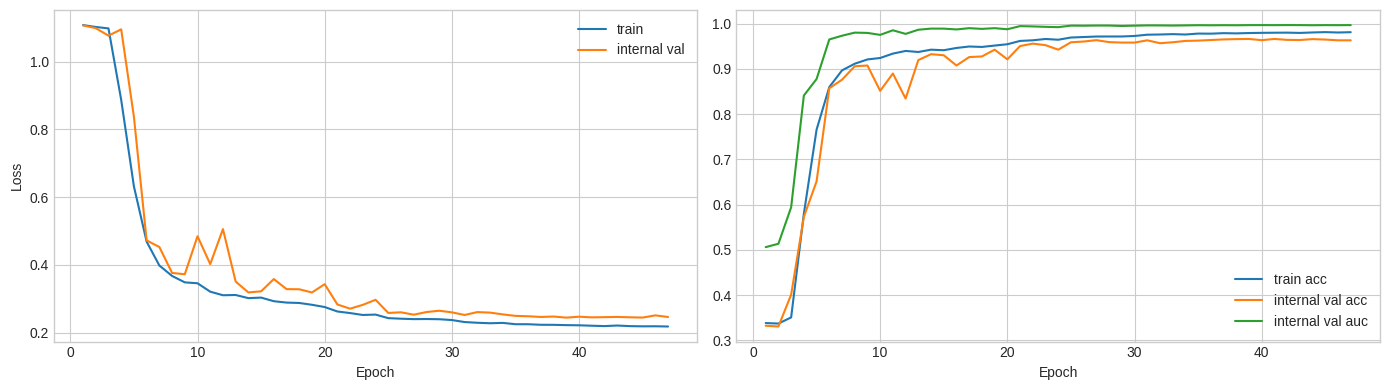

In [8]:
df = pd.DataFrame(history)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(df["epoch"], df["train_loss"], label="train")
ax1.plot(df["epoch"], df["val_loss"], label="internal val")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(df["epoch"], df["train_acc"], label="train acc")
ax2.plot(df["epoch"], df["val_acc"], label="internal val acc")
ax2.plot(df["epoch"], df["val_auc"], label="internal val auc")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()


## Internal Validation Evaluation

Run the primary post-training evaluation on the internal validation split. Standard single-pass metrics are reported first because they are the main reference for model quality; a symmetry-based TTA pass is then added as a supplemental inference-time comparison.


In [9]:
print("Running standard evaluation on internal validation split ...")
val_results = evaluate(model, val_loader, criterion)
val_true, val_pred, val_prob = summarize_split(
    "INTERNAL VALIDATION RESULTS (standard)", val_results
)

print()
print(f"Running symmetry-based TTA evaluation (n={TTA_N}) on internal validation split ...")
val_tta_results = evaluate_tta(model, val_paths, val_labels, criterion, n_aug=TTA_N)
val_tta_true, val_tta_pred, val_tta_prob = summarize_split(
    "INTERNAL VALIDATION RESULTS (TTA)", val_tta_results
)


Running standard evaluation on internal validation split ...
INTERNAL VALIDATION RESULTS (standard)
Loss: 0.2457
Accuracy: 0.9640
Macro AUC: 0.9967
Per-class AUC:
  no: 0.9968
  sphere: 0.9944
  vort: 0.9988
Classification Report:
              precision    recall  f1-score   support

          no       0.97      0.97      0.97      1000
      sphere       0.95      0.95      0.95      1000
        vort       0.98      0.97      0.97      1000

    accuracy                           0.96      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.96      0.96      0.96      3000


Running symmetry-based TTA evaluation (n=8) on internal validation split ...
INTERNAL VALIDATION RESULTS (TTA)
Loss: 0.2457
Accuracy: 0.9190
Macro AUC: 0.9911
Per-class AUC:
  no: 0.9965
  sphere: 0.9857
  vort: 0.9913
Classification Report:
              precision    recall  f1-score   support

          no       0.99      0.84      0.91      1000
      sphere       0.90      0.95   

## Holdout Evaluation

Run the one-time supplemental evaluation on `dataset/val`. This split is kept separate from checkpoint selection and is reported in both standard and TTA modes so the extra inference-time gain is visible without changing the training procedure.


In [10]:
print("Running standard evaluation on holdout split ...")
holdout_results = evaluate(model, holdout_loader, criterion)
y_true, y_pred, y_prob = summarize_split(
    "HOLDOUT RESULTS (SUPPLEMENTAL, standard)", holdout_results
)

print()
print(f"Running symmetry-based TTA evaluation (n={TTA_N}) on holdout split ...")
holdout_tta_results = evaluate_tta(
    model, holdout_paths, holdout_labels, criterion, n_aug=TTA_N
)
y_tta_true, y_tta_pred, y_tta_prob = summarize_split(
    "HOLDOUT RESULTS (SUPPLEMENTAL, TTA)", holdout_tta_results
)


Running standard evaluation on holdout split ...
HOLDOUT RESULTS (SUPPLEMENTAL, standard)
Loss: 0.2512
Accuracy: 0.9649
Macro AUC: 0.9954
Per-class AUC:
  no: 0.9961
  sphere: 0.9923
  vort: 0.9979
Classification Report:
              precision    recall  f1-score   support

          no       0.97      0.97      0.97      2500
      sphere       0.95      0.96      0.95      2500
        vort       0.98      0.97      0.98      2500

    accuracy                           0.96      7500
   macro avg       0.97      0.96      0.96      7500
weighted avg       0.97      0.96      0.96      7500


Running symmetry-based TTA evaluation (n=8) on holdout split ...
HOLDOUT RESULTS (SUPPLEMENTAL, TTA)
Loss: 0.2512
Accuracy: 0.9181
Macro AUC: 0.9909
Per-class AUC:
  no: 0.9955
  sphere: 0.9859
  vort: 0.9915
Classification Report:
              precision    recall  f1-score   support

          no       0.98      0.84      0.90      2500
      sphere       0.90      0.95      0.93      2500
  

## ROC Curves And Confusion Matrices

Visualize one-vs-rest ROC curves and confusion matrices for both evaluation splits in both standard and TTA modes. These plots complement the scalar metrics above and make it easier to see whether TTA changes classwise behavior or only smooths the final probabilities.


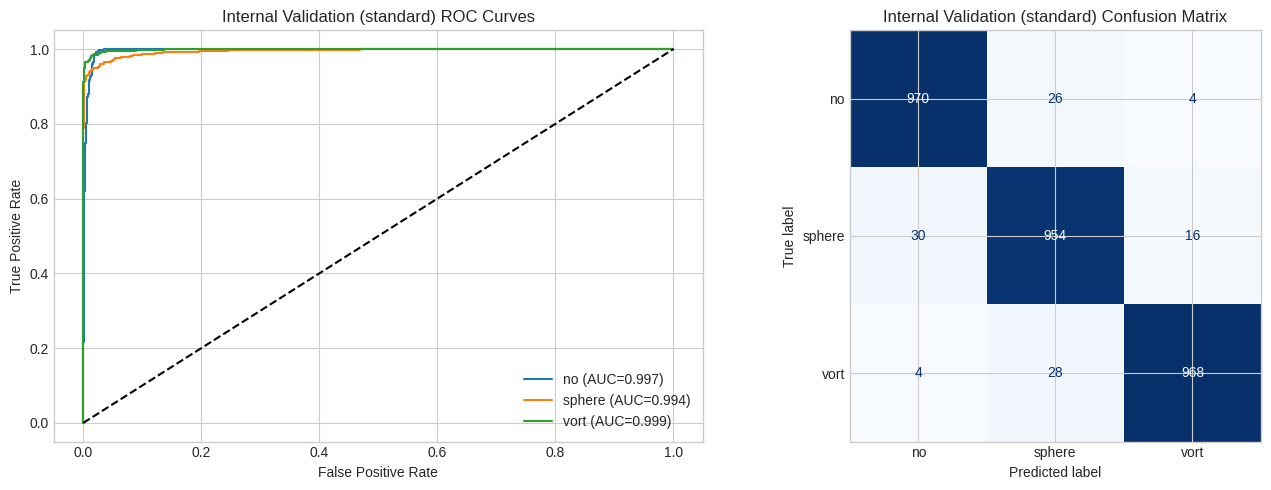

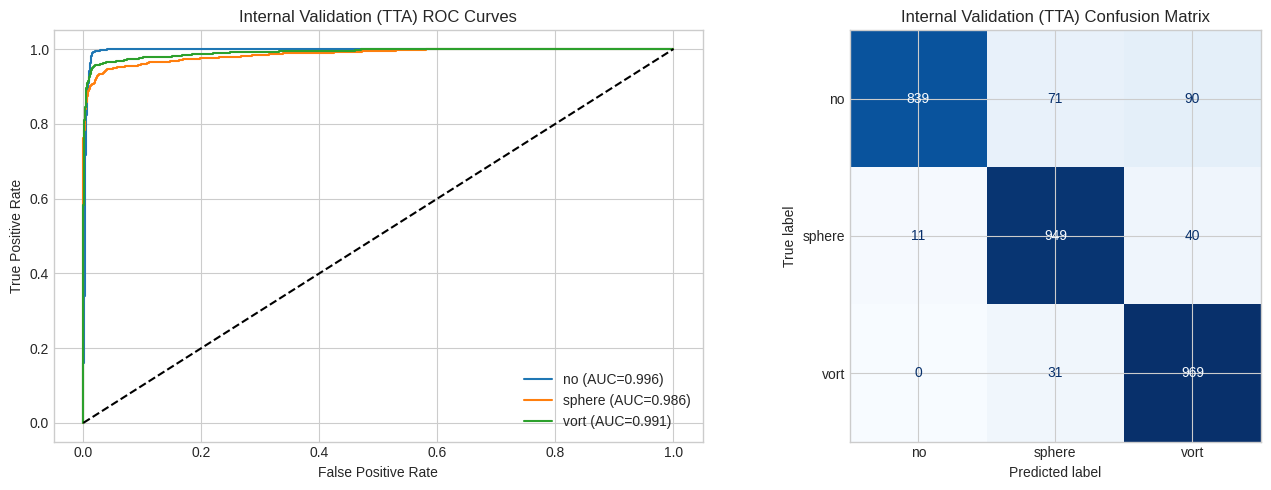

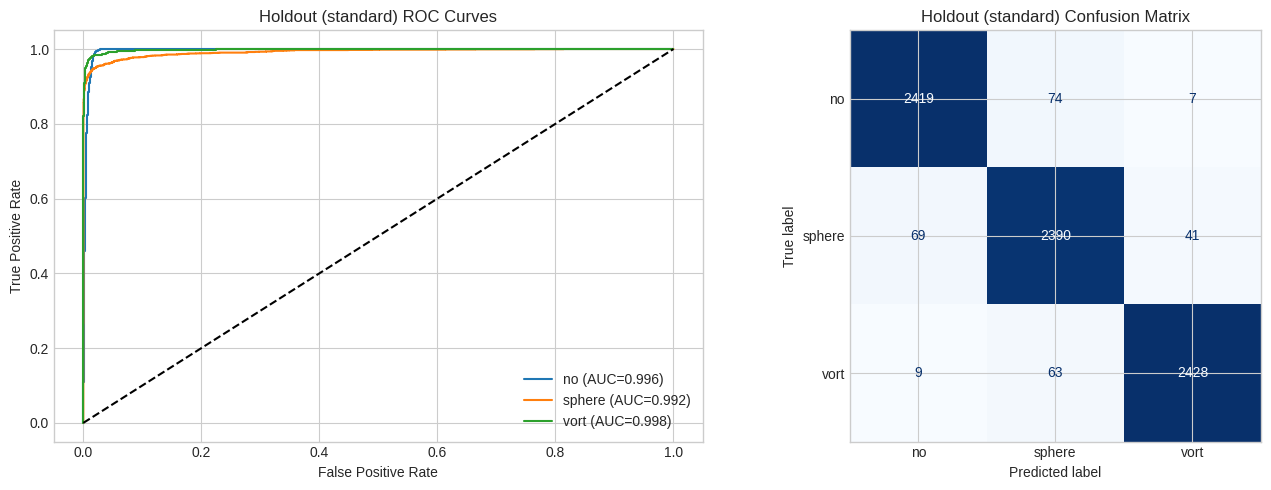

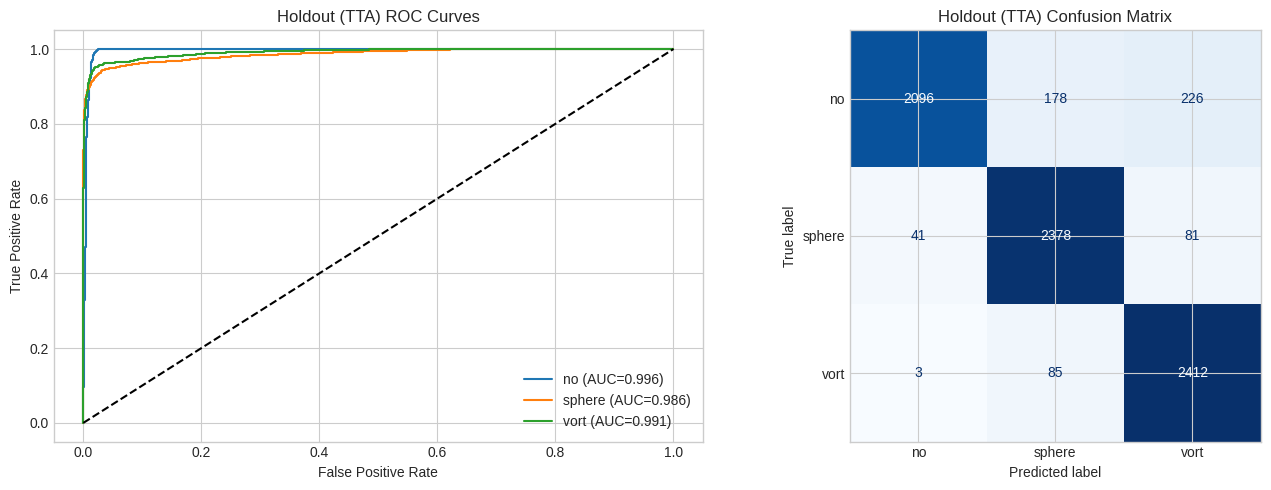

In [11]:
def plot_results(title, labels, predictions, probabilities):
    labels_bin = label_binarize(labels, classes=[0, 1, 2])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for i, class_name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probabilities[:, i])
        class_auc = roc_auc_score(labels_bin[:, i], probabilities[:, i])
        ax1.plot(fpr, tpr, label=f"{class_name} (AUC={class_auc:.3f})")

    ax1.plot([0, 1], [0, 1], "k--")
    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    ax1.set_title(f"{title} ROC Curves")
    ax1.legend()

    ConfusionMatrixDisplay.from_predictions(
        labels,
        predictions,
        display_labels=CLASS_NAMES,
        ax=ax2,
        cmap="Blues",
        colorbar=False,
    )
    ax2.set_title(f"{title} Confusion Matrix")

    plt.tight_layout()
    plt.show()


plot_results("Internal Validation (standard)", val_true, val_pred, val_prob)
plot_results("Internal Validation (TTA)", val_tta_true, val_tta_pred, val_tta_prob)
plot_results("Holdout (standard)", y_true, y_pred, y_prob)
plot_results("Holdout (TTA)", y_tta_true, y_tta_pred, y_tta_prob)
